In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


Dataset Understanding

In [11]:
import pandas as pd
df=pd.read_csv("/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [12]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
df.shape

(7043, 21)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Target Variable Analysis**

In [15]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Visualization:

<Axes: xlabel='Churn', ylabel='count'>

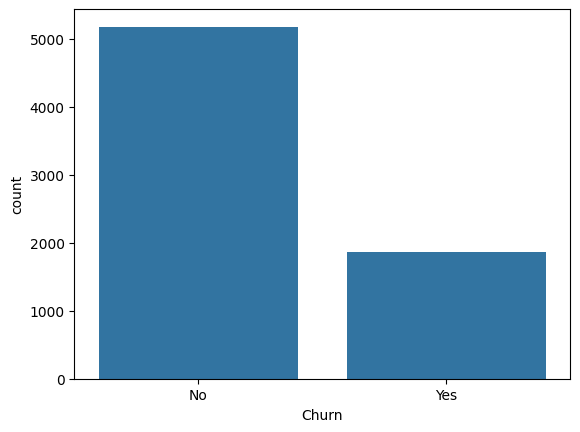

In [16]:
import seaborn as sns
sns.countplot(x="Churn",data=df)

Dataset is imbalanced.

Majority class:
No Churn

Minority class:
Churn

# Missing Value Analysis

In [17]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [18]:
df[df['TotalCharges']==" "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


# EDA

Gender vs Churn

<Axes: xlabel='gender', ylabel='count'>

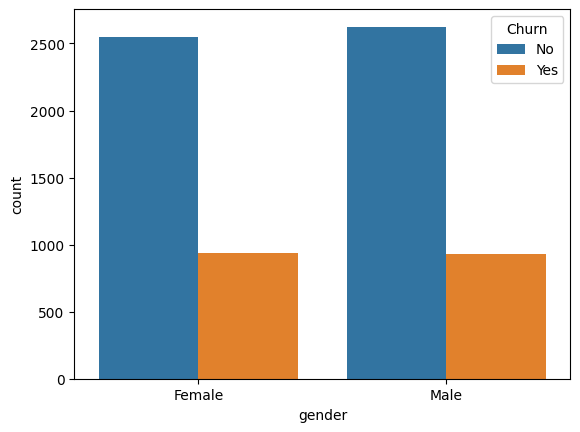

In [19]:
sns.countplot(
    x='gender',
    hue='Churn',
    data=df
)

Observation:

Male and Female customers have similar churn rates.

**Contract vs Churn**

<Axes: xlabel='Contract', ylabel='count'>

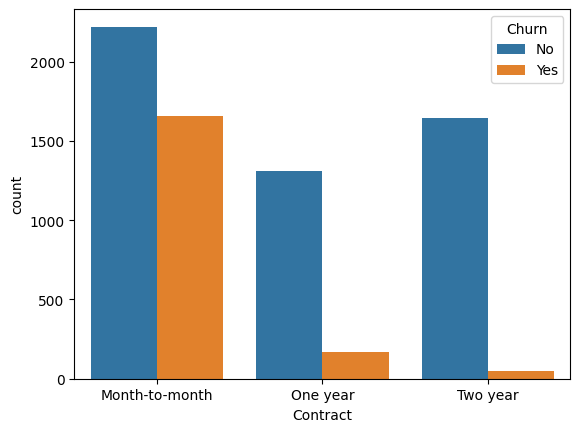

In [20]:
sns.countplot(
    x='Contract',
    hue='Churn',
    data=df
)

**Internet Service vs Churn**

<Axes: xlabel='InternetService', ylabel='count'>

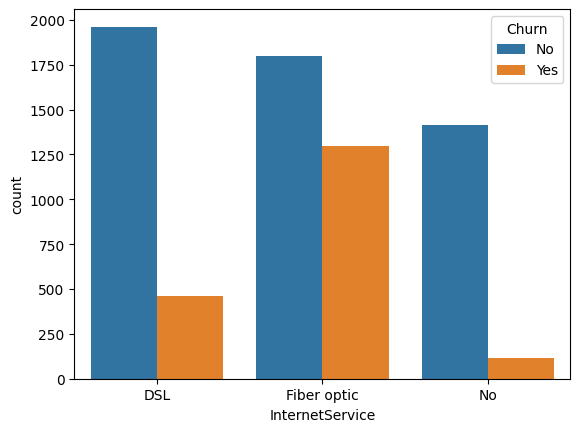

In [21]:
sns.countplot(
    x='InternetService',
    hue='Churn',
    data=df
)

**Tenure Distribution**

<Axes: xlabel='tenure', ylabel='Count'>

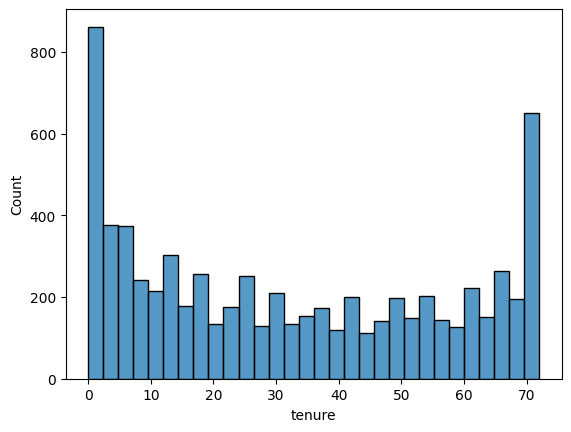

In [22]:
sns.histplot(
    df['tenure'],
    bins=30
)

Short-tenure customers
are more likely to churn.

**Correlation Analysis**

In [29]:
numeric_df = df.select_dtypes(
    include=['number']
)

**Heatmap:**

<Axes: >

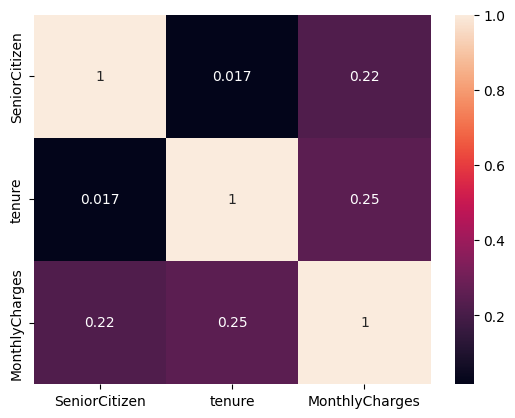

In [30]:
sns.heatmap(
    numeric_df.corr(),
    annot=True
)

# Data Preprocessing

In [34]:
df.drop(
    'customerID',
    axis=1,
    inplace=True
)

KeyError: "['customerID'] not found in axis"

In [35]:
# customerID ড্রপ করা (errors='ignore' দিলে দ্বিতীয়বার রান করলেও এরর আসবে না)
df.drop('customerID', axis=1, inplace=True, errors='ignore')

# TotalCharges কলামের খালি স্পেসকে NaN দিয়ে পরিবর্তন করা
import numpy as np
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)

# যেহেতু মাত্র ১১টি সারি খালি এবং তাদের tenure = 0, আমরা এই সারিগুলো ড্রপ করে দিতে পারি
df.dropna(subset=['TotalCharges'], inplace=True)

# কলামটিকে অবজেক্ট থেকে ফ্লোট (float) এ রূপান্তর করা
df['TotalCharges'] = df['TotalCharges'].astype(float)

# যাচাই করা
print("Total Missing Values Now:", df.isnull().sum().sum())
print("TotalCharges Data Type:", df['TotalCharges'].dtype)


Total Missing Values Now: 0
TotalCharges Data Type: float64


**(Encoding)**

In [36]:
# টার্গেট ভ্যারিয়েবল 'Churn' কে বাইনারিতে রূপান্তর (Yes = 1, No = 0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# বাকি সব ক্যাটাগরিকাল কলামের জন্য One-Hot Encoding করা
# drop_first=True দিলে মাল্টিকলিনিয়ারিটি (Multicollinearity) এড়ানো যায়
df_encoded = pd.get_dummies(df, drop_first=True)

# কলামগুলো বুলিয়ান (True/False) থেকে সংখ্যায় (1/0) রূপান্তর করা
df_encoded = df_encoded.astype(int)

# ডেটাসেটের নতুন আকার দেখা
print("Encoded Dataset Shape:", df_encoded.shape)
df_encoded.head()


Encoded Dataset Shape: (7032, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29,29,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56,1889,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53,108,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42,1840,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70,151,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


# 

In [38]:
from sklearn.model_selection import train_test_split

# ফিচার এবং টার্গেট আলাদা করা
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Train and Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")


Training set size: (5625, 30)
Testing set size: (1407, 30)


# Scaling & Handle Imbalance (SMOTE)

In [39]:
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# ১. প্রথমে ডেটাকে Train এবং Test সেটে ভাগ করা (৮০% - ২০%)
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ২. Phase 8: Scaling (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ফিউচার অ্যাপে ব্যবহারের জন্য Scaler সেভ করা
joblib.dump(scaler, "scaler.pkl")
print("✅ Scaler saved successfully as 'scaler.pkl'")

# ৩. Phase 9: SMOTE (Handle Imbalance)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Original Train Set Size: {X_train_scaled.shape[0]}")
print(f"SMOTE Balanced Train Set Size: {X_train_smote.shape[0]}")


✅ Scaler saved successfully as 'scaler.pkl'
Original Train Set Size: 5625
SMOTE Balanced Train Set Size: 8260


# Train Models 3 Different Model


In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Model 1: Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_smote, y_train_smote)
print("✅ Logistic Regression Model Trained!")

# Model 2: Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_smote, y_train_smote)
print("✅ Random Forest Model Trained!")

# Model 3: XGBoost
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train_smote, y_train_smote)
print("✅ XGBoost Model Trained!")


✅ Logistic Regression Model Trained!
✅ Random Forest Model Trained!
✅ XGBoost Model Trained!


# Cross Validation

In [41]:
from sklearn.model_selection import cross_val_score

# ৫-ফোল্ড ক্রস ভ্যালিডেশন
scores = cross_val_score(rf, X_train_smote, y_train_smote, cv=5, scoring='accuracy')

print("Cross Validation Scores for each fold:", scores)
print(f"Average Cross Validation Score: {scores.mean() * 100:.2f}%")


Cross Validation Scores for each fold: [0.781477   0.80387409 0.88922518 0.89769976 0.90133172]
Average Cross Validation Score: 85.47%


# Hyperparameter Tuning (Random Forest এর সেটিংস টিউনিং)

In [45]:
from sklearn.model_selection import GridSearchCV

# সেটিংসের অপশনগুলো নির্ধারণ করা (এখানে সঠিক মানগুলো বসিয়ে দেওয়া হয়েছে)
param_grid = {
    'n_estimators':[100,200],
    'max_depth': [5, 10, None]
}

# GridSearchCV সেটআপ করা
grid = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, scoring='f1', n_jobs=-1)
grid.fit(X_train_smote, y_train_smote)

# সেরা সেটিংস এবং সেরা মডেলটি আলাদা করা
best_rf_model = grid.best_estimator_
print("✅ Best Hyperparameters Found:", grid.best_params_)


✅ Best Hyperparameters Found: {'max_depth': None, 'n_estimators': 200}


#  Evaluation & Comparison Table

In [46]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score

# ১. মডেলগুলোর একটি ডিকশনারি তৈরি
models = {
    'Logistic Regression': lr,
    'Tuned Random Forest': best_rf_model,
    'XGBoost': xgb
}

# ২. মেট্রিকস জেনারেট করার লুপ
results = []

for model_name, model in models.items():
    # প্রেডিকশন এবং প্রবাবিলিটি বের করা
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    # স্কোর হিসাব করা
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    
    # রেজাল্ট লিস্টে অ্যাপেন্ড করা
    results.append({
        'Model': model_name,
        'Accuracy': f'{(acc * 100):.2f}%',
        'Precision': f'{(prec * 100):.2f}%',
        'Recall': f'{(rec * 100):.2f}%',
        'F1-Score': f'{(f1 * 100):.2f}%',
        'ROC-AUC': f'{roc:.4f}'
    })

# ৩. সুন্দর একটি পান্ডাস ডেটাফ্রেম বা টেবিল বানানো
comparison_df = pd.DataFrame(results)
print("\n📊 MODEL COMPARISON TABLE:")
display(comparison_df)



📊 MODEL COMPARISON TABLE:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,73.21%,49.74%,78.07%,60.77%,0.8342
1,Tuned Random Forest,77.47%,57.44%,58.82%,58.12%,0.8187
2,XGBoost,76.90%,56.20%,59.36%,57.74%,0.8136


#  Confusion Matrix & ROC Curve Visualization

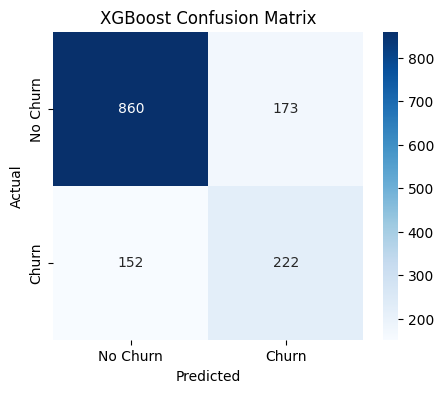

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# বেস্ট মডেল হিসেবে আমরা যদি XGBoost বা Tuned RF কে ধরি, তার কনফিউশন ম্যাট্রিক্স দেখা যাক
# এখানে XGBoost এর কনফিউশন ম্যাট্রিক্স প্লট করা হলো
y_pred_xgb = xgb.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('XGBoost Confusion Matrix')
plt.show()


# Feature Importance

/tmp/ipykernel_58/3215396825.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_importance_df, palette='coolwarm')


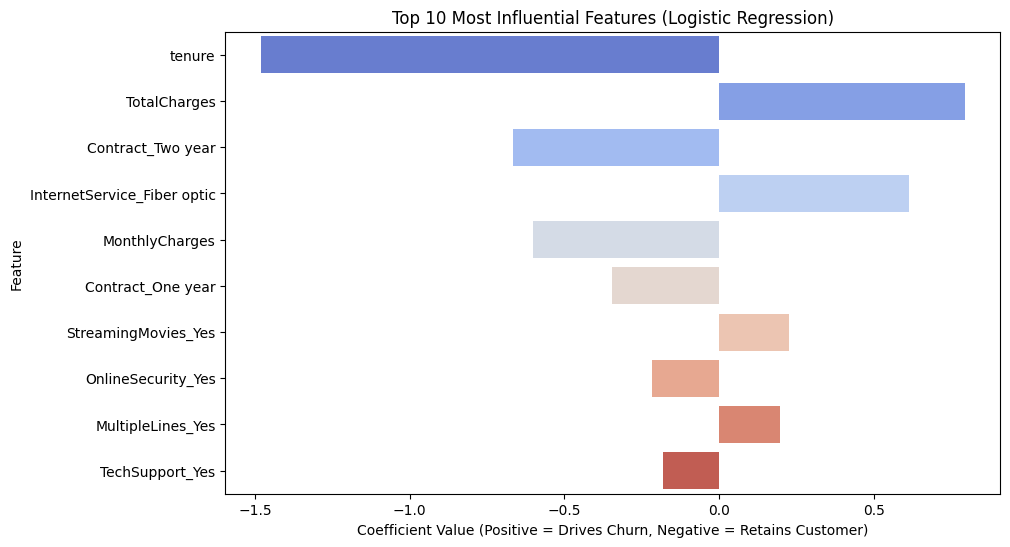

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # এখানে সঠিক করে দেওয়া হয়েছে

# লজিস্টিক রিগ্রেশনের কো-ফিশিয়েন্ট বা গুরুত্ব বের করা
importance = lr.coef_[0]  # ২D অ্যারে থেকে ১D তে নেওয়ার জন্য [0] যোগ করা হয়েছে
feature_names = X.columns

# একটি ডেটাফ্রেম তৈরি করে সর্ট করা
feat_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
feat_importance_df['Absolute_Importance'] = feat_importance_df['Importance'].abs()
feat_importance_df = feat_importance_df.sort_values(by='Absolute_Importance', ascending=False).head(10)

# প্লট করা
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_importance_df, palette='coolwarm')
plt.title('Top 10 Most Influential Features (Logistic Regression)')
plt.xlabel('Coefficient Value (Positive = Drives Churn, Negative = Retains Customer)')
plt.show()


# SHAP Explainability 

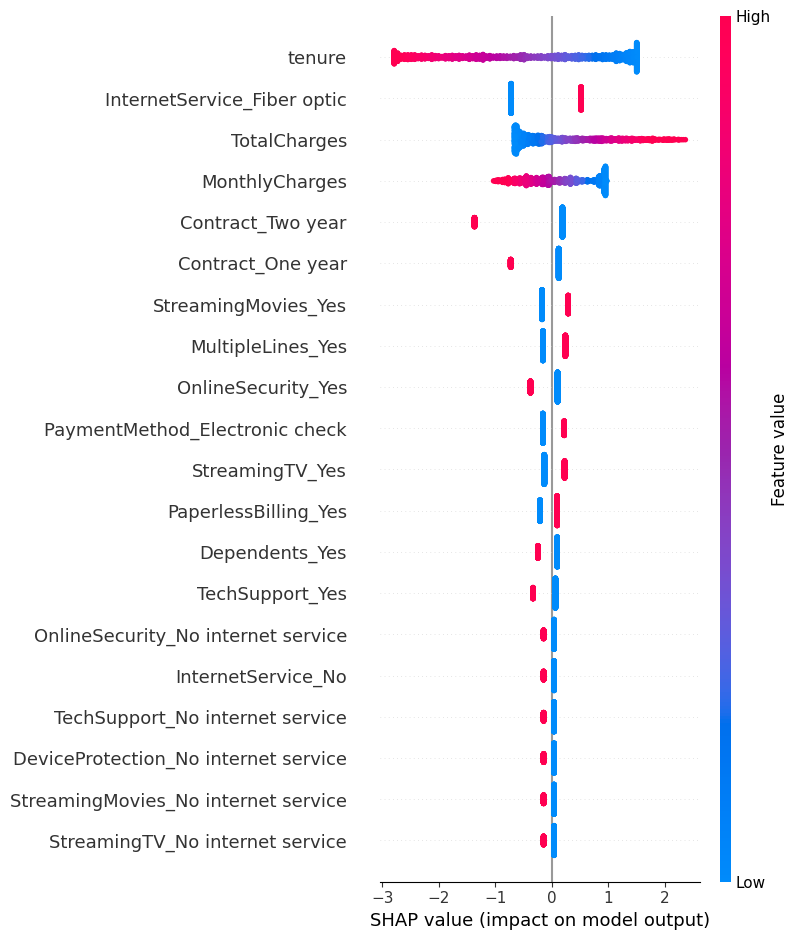

In [51]:
import shap
import matplotlib.pyplot as plt

# লজিস্টিক রিগ্রেশনের জন্য এক্সপেইনার তৈরি (ভ্যারিয়েবল নাম ফিক্স করা হয়েছে)
explainer = shap.LinearExplainer(lr, X_train_smote) 
shap_values = explainer(X_test_scaled)

# সামারি প্লট তৈরি করা
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)


# Save the Best Model

In [56]:
import joblib

# লজিস্টিক রিগ্রেশন মডেলটি সেভ করা
joblib.dump(lr, "churn_model.pkl")
print("✅ Best Model (Logistic Regression) saved successfully as 'churn_model.pkl'!")


✅ Best Model (Logistic Regression) saved successfully as 'churn_model.pkl'!


In [57]:
from IPython.display import FileLink

# মডলে ফাইল ডাউনলোডের লিংক
display(FileLink(r'churn_model.pkl'))

/kaggle/working/churn_model.pkl

In [58]:
# স্কেলার ফাইল ডাউনলোডের লিংক
display(FileLink(r'scaler.pkl'))

/kaggle/working/scaler.pkl